
✅ Дані успішно завантажено. Об'єктів: 284807, Колонок: 31

1. Ознаки 'Time' та 'Amount' успішно масштабовано.
Розмір навчального набору (train): 227845 об'єктів.
Розмір тестового набору (test): 56962 об'єктів.
Кількість випадків шахрайства (1) у тестовому наборі: 98

✅ Модель Логістичної Регресії успішно навчена.

--- Метрики Класифікації ---
1. Accuracy (Загальна Точність): 0.9755 (Будьте обережні з цією метрикою!)
2. F1-score (Баланс Precision/Recall): 0.1141
3. Precision (Точність позитивного класу): 0.0609
4. Recall (Повнота позитивного класу): 0.9184

Матриця Плутанини (Confusion Matrix):
 [[55475  1389]
 [    8    90]]


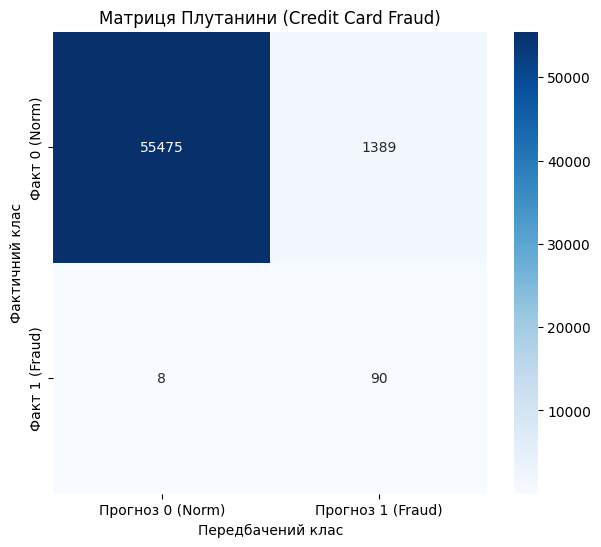

In [2]:
# =========================================================
# ЛР №5: Класифікація (Набір Credit Card Fraud Detection)
# =========================================================

# 1. ІМПОРТ НЕОБХІДНИХ БІБЛІОТЕК
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression 
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.preprocessing import StandardScaler # ДОДАНО для масштабування!
import matplotlib.pyplot as plt 
import seaborn as sns 

# 2. КОНСТАНТИ
FILE_NAME = 'creditcard.csv' 
Y_TARGET = 'Class' # Ціль: 0 (не шахрайство) або 1 (шахрайство)
RANDOM_SEED = 42

# 3. Завантаження даних
try:
    df_fraud = pd.read_csv(FILE_NAME)
    print(f"\n✅ Дані успішно завантажено. Об'єктів: {df_fraud.shape[0]}, Колонок: {df_fraud.shape[1]}")
except FileNotFoundError:
    print(f"\n❌ Помилка: Файл '{FILE_NAME}' не знайдено.")
    exit()

# 4. Визначення ознак
# Усі V-ознаки вже нормалізовані. Нам потрібно масштабувати 'Time' та 'Amount'.
SCALER_FEATURES = ['Time', 'Amount']
# Усі V-ознаки (V1-V28) + масштабовані ознаки
X_FEATURES = [col for col in df_fraud.columns if col not in ['Class', 'Time', 'Amount']]
X_FEATURES.extend(SCALER_FEATURES)


# =========================================================
# ЕТАП 2: ПОПЕРЕДНЯ ОБРОБКА ТА ПІДГОТОВКА ДАНИХ
# =========================================================

df_clean = df_fraud.copy()

# 1. Масштабування ознак 'Time' та 'Amount'
scaler = StandardScaler()
df_clean['Scaled_Time'] = scaler.fit_transform(df_clean['Time'].values.reshape(-1, 1))
df_clean['Scaled_Amount'] = scaler.fit_transform(df_clean['Amount'].values.reshape(-1, 1))
print("\n1. Ознаки 'Time' та 'Amount' успішно масштабовано.")

# 2. Вибір фінального набору ознак
FINAL_X_FEATURES = X_FEATURES[:-2] # Усі V-ознаки
FINAL_X_FEATURES.extend(['Scaled_Time', 'Scaled_Amount']) # Додаємо масштабовані

X = df_clean[FINAL_X_FEATURES]
y = df_clean[Y_TARGET]

# 3. Розбиття на навчальний (train) та тестовий (test) набори (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_SEED, stratify=y # Stratify для незбалансованих даних!
)

print(f"Розмір навчального набору (train): {X_train.shape[0]} об'єктів.")
print(f"Розмір тестового набору (test): {X_test.shape[0]} об'єктів.")
print(f"Кількість випадків шахрайства (1) у тестовому наборі: {y_test.sum()}")


# =========================================================
# ЕТАП 3: МОДЕЛЮВАННЯ ТА ОЦІНКА
# =========================================================

# 1. Навчання моделі
# Використовуємо 'class_weight' для компенсації незбалансованості класів (опціонально, але рекомендовано)
model_clf = LogisticRegression(random_state=RANDOM_SEED, max_iter=1000, class_weight='balanced') 
model_clf.fit(X_train, y_train)
print("\n✅ Модель Логістичної Регресії успішно навчена.")

# 2. Прогноз на тестовому наборі
y_pred_clf = model_clf.predict(X_test)


# 3. Оцінка моделі за метриками КЛАСИФІКАЦІЇ
print("\n--- Метрики Класифікації ---")

accuracy = accuracy_score(y_test, y_pred_clf)
print(f"1. Accuracy (Загальна Точність): {accuracy:.4f} (Будьте обережні з цією метрикою!)")

f1 = f1_score(y_test, y_pred_clf)
print(f"2. F1-score (Баланс Precision/Recall): {f1:.4f}")

precision = precision_score(y_test, y_pred_clf)
print(f"3. Precision (Точність позитивного класу): {precision:.4f}")

recall = recall_score(y_test, y_pred_clf)
print(f"4. Recall (Повнота позитивного класу): {recall:.4f}")


# =========================================================
# ЕТАП 4: ВІЗУАЛІЗАЦІЯ (Матриця Плутанини)
# =========================================================

cm = confusion_matrix(y_test, y_pred_clf)
print("\nМатриця Плутанини (Confusion Matrix):\n", cm)

plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Прогноз 0 (Norm)', 'Прогноз 1 (Fraud)'],
            yticklabels=['Факт 0 (Norm)', 'Факт 1 (Fraud)'])
plt.title('Матриця Плутанини (Credit Card Fraud)')
plt.ylabel('Фактичний клас')
plt.xlabel('Передбачений клас')
plt.show()